# Monte Carlo Methods

Monte Carlo (MC) methods estimate value functions by **averaging returns** observed from
complete episodes. Unlike Dynamic Programming, MC does **not need a model** of the environment
(no transition probabilities required) - it learns purely from experience/sampling.

Two common variants:

1. **First-Visit MC** - only the first time a state is visited in an episode is used to update its value.
2. **Every-Visit MC** - every occurrence of the state in the episode is used.

### Return

G_t = R_t+1 + γ*R_t+2 + γ^2*R_t+3 + ...


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random


In [2]:
# Grid World Setup (same as before)

rows = 4
cols = 4

goal_state = (3, 3)
actions = ["UP", "DOWN", "LEFT", "RIGHT"]

reward = np.full((rows, cols), -1)
reward[goal_state] = 10

def next_state(state, action):
    row, col = state

    if action == "UP":
        row = max(row - 1, 0)
    elif action == "DOWN":
        row = min(row + 1, rows - 1)
    elif action == "LEFT":
        col = max(col - 1, 0)
    elif action == "RIGHT":
        col = min(col + 1, cols - 1)

    return (row, col)


## Episode Generation

Using a random policy to generate complete episodes (state, action, reward) until the goal is reached.

In [3]:
def generate_episode(max_steps=50):
    state = (0, 0)
    episode = []

    for _ in range(max_steps):
        action = random.choice(actions)
        ns = next_state(state, action)
        r = reward[ns]

        episode.append((state, action, r))

        state = ns

        if state == goal_state:
            break

    return episode

ep = generate_episode()
print("Sample Episode (state, action, reward):")
for step in ep:
    print(step)


Sample Episode (state, action, reward):
((0, 0), 'LEFT', np.int64(-1))
((0, 0), 'RIGHT', np.int64(-1))
((0, 1), 'RIGHT', np.int64(-1))
((0, 2), 'RIGHT', np.int64(-1))
((0, 3), 'DOWN', np.int64(-1))
((1, 3), 'RIGHT', np.int64(-1))
((1, 3), 'LEFT', np.int64(-1))
((1, 2), 'LEFT', np.int64(-1))
((1, 1), 'LEFT', np.int64(-1))
((1, 0), 'RIGHT', np.int64(-1))
((1, 1), 'LEFT', np.int64(-1))
((1, 0), 'UP', np.int64(-1))
((0, 0), 'DOWN', np.int64(-1))
((1, 0), 'UP', np.int64(-1))
((0, 0), 'LEFT', np.int64(-1))
((0, 0), 'LEFT', np.int64(-1))
((0, 0), 'UP', np.int64(-1))
((0, 0), 'DOWN', np.int64(-1))
((1, 0), 'LEFT', np.int64(-1))
((1, 0), 'LEFT', np.int64(-1))
((1, 0), 'UP', np.int64(-1))
((0, 0), 'RIGHT', np.int64(-1))
((0, 1), 'DOWN', np.int64(-1))
((1, 1), 'UP', np.int64(-1))
((0, 1), 'DOWN', np.int64(-1))
((1, 1), 'DOWN', np.int64(-1))
((2, 1), 'UP', np.int64(-1))
((1, 1), 'DOWN', np.int64(-1))
((2, 1), 'RIGHT', np.int64(-1))
((2, 2), 'DOWN', np.int64(-1))
((3, 2), 'RIGHT', np.int64(10))


## First-Visit Monte Carlo Prediction

In [4]:
gamma = 0.9
num_episodes = 500

def first_visit_mc():
    V = np.zeros((rows, cols))
    returns_sum = np.zeros((rows, cols))
    returns_count = np.zeros((rows, cols))

    for _ in range(num_episodes):
        episode = generate_episode()
        G = 0
        visited = set()

        for t in reversed(range(len(episode))):
            state, action, r = episode[t]
            G = gamma * G + r

            if state not in visited:
                visited.add(state)
                returns_sum[state] += G
                returns_count[state] += 1
                V[state] = returns_sum[state] / returns_count[state]

    return V

V_first_visit = first_visit_mc()
print(V_first_visit)


[[-6.24663233 -5.46326835 -4.77621987 -4.53376485]
 [-5.23412478 -4.11851983 -3.28330529 -2.70215601]
 [-4.453787   -2.55758376 -0.70769856  1.82769719]
 [-4.0139038  -1.90136258  2.35843533  0.        ]]


## Every-Visit Monte Carlo Prediction

In [5]:
def every_visit_mc():
    V = np.zeros((rows, cols))
    returns_sum = np.zeros((rows, cols))
    returns_count = np.zeros((rows, cols))

    for _ in range(num_episodes):
        episode = generate_episode()
        G = 0

        for t in reversed(range(len(episode))):
            state, action, r = episode[t]
            G = gamma * G + r

            returns_sum[state] += G
            returns_count[state] += 1
            V[state] = returns_sum[state] / returns_count[state]

    return V

V_every_visit = every_visit_mc()
print(V_every_visit)


[[-8.09367131 -7.70676828 -7.1197773  -6.54512764]
 [-7.51880824 -7.12459714 -6.11594118 -4.77847907]
 [-6.98632274 -6.08443143 -3.9061391  -0.25658389]
 [-6.38219634 -4.83633574 -0.72212784  0.        ]]


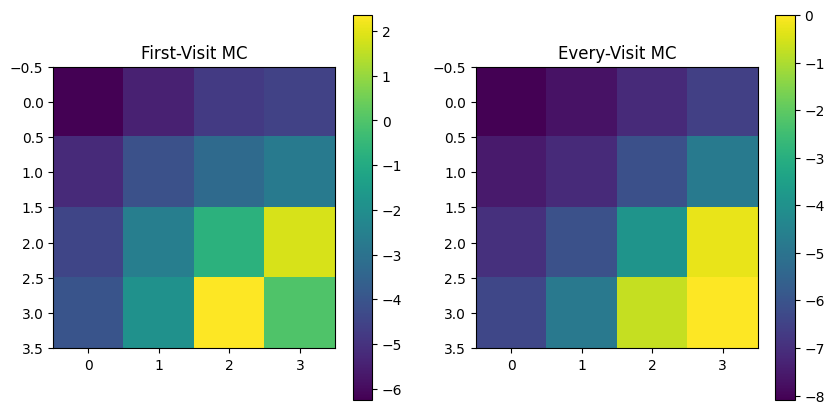

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

im0 = axes[0].imshow(V_first_visit, cmap="viridis")
axes[0].set_title("First-Visit MC")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(V_every_visit, cmap="viridis")
axes[1].set_title("Every-Visit MC")
plt.colorbar(im1, ax=axes[1])

plt.show()


## Conclusion

Both First-Visit and Every-Visit Monte Carlo converge towards similar value estimates near
the goal state, as more episodes reach it and averaging smooths out the noise from the random
policy. Monte Carlo needs **complete episodes** before it can update any value, unlike TD
methods which can update after every single step.
